# Phase 1A — Whole-team defensive centroid diagnostics

**Scope:** test one simple structural reference on Metrica Sample Game 1: the leave-one-out centroid of the other defending outfield players. This notebook does not implement states, classifications, thresholds, ambiguity, smoothing, velocities, derivatives, HMMs, machine learning, tactical-role inference, alternative structural references, or any composite score.

The exercise is diagnostic. Three short sequences and the focal players were selected manually after viewing raw trajectories. Their descriptions are visual prompts, not tactical ground-truth labels.

## 1. Data and minimal parsing

This notebook uses the same checksum-verified Metrica Sample Game 1 files as Phase 0. Coordinates remain in the raw nominally normalized system, including values outside `[0,1]`. No flipping, metric conversion, interpolation, or normalization is applied.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'README.md').exists() and (REPO_ROOT.parent / 'README.md').exists():
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / 'data' / 'metrica_sample_game_1'
DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = 'https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1'
FILES = {
    'home': ('Sample_Game_1_RawTrackingData_Home_Team.csv', '0a3d0eff7785950379c587d3597b86a2d91c2492281b4652e1abb97c99b6b364'),
    'away': ('Sample_Game_1_RawTrackingData_Away_Team.csv', '0a3df68a92af0290ede472e62de3b6489ddee29223da09bdf0cf76c8e0ab0618'),
    'events': ('Sample_Game_1_RawEventsData.csv', '097dda6345e17390dca095331458fd00e47960c480c76f4356fd4edf2575ef05'),
}

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

for filename, expected_hash in FILES.values():
    path = DATA_DIR / filename
    if not path.exists():
        urlretrieve(f'{BASE_URL}/{filename}', path)
    if sha256(path) != expected_hash:
        raise ValueError(f'Checksum mismatch: {filename}')
paths = {key: DATA_DIR / value[0] for key, value in FILES.items()}

def load_tracking(path):
    header = pd.read_csv(path, header=None, nrows=3)
    player_ids = [str(int(float(value))) for value in header.iloc[1, 3:-2:2] if pd.notna(value)]
    columns = ['Period', 'Frame', 'Time [s]']
    for player_id in player_ids:
        columns.extend([f'Player{player_id}_x', f'Player{player_id}_y'])
    columns.extend(['Ball_x', 'Ball_y'])
    return pd.read_csv(path, skiprows=3, names=columns), player_ids

home, home_players = load_tracking(paths['home'])
away, away_players = load_tracking(paths['away'])
events = pd.read_csv(paths['events'])
print({'home': home.shape, 'away': away.shape, 'events': events.shape})

{'home': (145006, 33), 'away': (145006, 33), 'events': (1745, 14)}


## 2. Reference definition and manual diagnostic choices

For every frame in a selected window, let the focal defender be Home Player2 and let Home Player11 be the goalkeeper excluded from the reference. These choices are manual and match-specific: Player11's sustained end-line position and halftime end switch were documented in Phase 0, while Player2 was visually chosen as an outfield member of the defending shape. This is not an algorithm for inferring tactical roles.

The reference uses the nine other coordinate-present Home outfield players in each window. Players 1, 3, 4, 5, 6, 7, 8, 9, and 10 are present in the 590–598s and 770–778s windows. In the later 1888–1896s window, Player1 is absent and Player12 is present, so Player12 replaces Player1. This is explicit lineup availability handling, not imputation or role inference. At each raw frame:

`centroid_x(t) = arithmetic mean of the nine reference-player x coordinates`

`centroid_y(t) = arithmetic mean of the nine reference-player y coordinates`

`relative_x(t) = focal_x(t) - centroid_x(t)`

`relative_y(t) = focal_y(t) - centroid_y(t)`

Longitudinal x and lateral y remain separate. No distance, norm, weighting, smoothing, or combined structural quantity is calculated.

In [2]:
FOCAL_ID = '2'
GOALKEEPER_ID = '11'
REFERENCE_IDS_BY_SEQUENCE = {
    'coordinated': ['3', '4', '5', '6', '7', '8', '9', '10', '12'],
    'excursion': ['1', '3', '4', '5', '6', '7', '8', '9', '10'],
    'messy': ['1', '3', '4', '5', '6', '7', '8', '9', '10'],
}
MANUAL_ATTACKER_ID = '23'

SEQUENCES = {
    'coordinated': {
        'period': 1, 'start_s': 1888.0, 'end_s': 1896.0,
        'description': 'reasonably coordinated collective defensive movement',
        'selection_note': 'The Home outfield paths visually translate in broadly parallel directions during an Away passing phase.',
    },
    'excursion': {
        'period': 1, 'start_s': 590.0, 'end_s': 598.0,
        'description': 'apparent individual excursion toward an opponent',
        'selection_note': 'Home Player2 departs from the broader Home movement and moves toward manually identified Away Player23.',
    },
    'messy': {
        'period': 1, 'start_s': 770.0, 'end_s': 778.0,
        'description': 'messy transition / broken-shape situation',
        'selection_note': 'The Home paths visibly diverge during an Away passing sequence ending in a deep ball.',
    },
}

def sequence_rows(df, specification):
    return df.loc[
        (df['Period'] == specification['period'])
        & df['Time [s]'].between(specification['start_s'], specification['end_s'])
    ].copy()

def add_leave_one_out_centroid(frame, reference_ids):
    frame = frame.copy()
    frame['centroid_x'] = frame[[f'Player{pid}_x' for pid in reference_ids]].mean(axis=1)
    frame['centroid_y'] = frame[[f'Player{pid}_y' for pid in reference_ids]].mean(axis=1)
    frame['relative_x'] = frame[f'Player{FOCAL_ID}_x'] - frame['centroid_x']
    frame['relative_y'] = frame[f'Player{FOCAL_ID}_y'] - frame['centroid_y']
    return frame

diagnostics = {}
for name, specification in SEQUENCES.items():
    reference_ids = REFERENCE_IDS_BY_SEQUENCE[name]
    home_window = add_leave_one_out_centroid(sequence_rows(home, specification), reference_ids)
    away_window = sequence_rows(away, specification)
    diagnostics[name] = (home_window, away_window)
    required_columns = [f'Player{pid}_{axis}' for pid in [FOCAL_ID] + reference_ids for axis in ('x', 'y')]
    print(name, {
        'frames': len(home_window),
        'duration_s': home_window['Time [s]'].iloc[-1] - home_window['Time [s]'].iloc[0],
        'reference_ids': reference_ids,
        'missing_required_coordinate_values': int(home_window[required_columns].isna().sum().sum()),
        'description': specification['description'],
    })

coordinated {'frames': 201, 'duration_s': np.float64(8.0), 'reference_ids': ['3', '4', '5', '6', '7', '8', '9', '10', '12'], 'missing_required_coordinate_values': 0, 'description': 'reasonably coordinated collective defensive movement'}
excursion {'frames': 201, 'duration_s': np.float64(8.0), 'reference_ids': ['1', '3', '4', '5', '6', '7', '8', '9', '10'], 'missing_required_coordinate_values': 0, 'description': 'apparent individual excursion toward an opponent'}
messy {'frames': 201, 'duration_s': np.float64(8.0), 'reference_ids': ['1', '3', '4', '5', '6', '7', '8', '9', '10'], 'missing_required_coordinate_values': 0, 'description': 'messy transition / broken-shape situation'}


## 3. Event context and selection limitations

Event rows are contextual only. They neither prove possession throughout a window nor determine the diagnostic description. The sequence choices were made by looking at raw paths, and nearby events were inspected afterward.

In [3]:
context_rows = []
for name, specification in SEQUENCES.items():
    event_end = events['End Time [s]'].where(events['End Time [s]'] > 0, events['Start Time [s]'])
    overlaps = events.loc[
        (events['Period'] == specification['period'])
        & (events['Start Time [s]'] <= specification['end_s'])
        & (event_end >= specification['start_s']),
        ['Team', 'Type', 'Subtype', 'Start Time [s]', 'End Time [s]', 'From', 'To'],
    ].copy()
    overlaps.insert(0, 'diagnostic_sequence', name)
    context_rows.append(overlaps)
display(pd.concat(context_rows, ignore_index=True))

selection_notes = pd.DataFrame([
    {'sequence': name, 'window': f"P{spec['period']} {spec['start_s']:.0f}–{spec['end_s']:.0f}s", 'manual_visual_rationale': spec['selection_note']}
    for name, spec in SEQUENCES.items()
]).set_index('sequence')
display(selection_notes)

,diagnostic_sequence,Team,Type,Subtype,Start Time [s],End Time [s],From,To
0,coordinated,Away,PASS,NaN,1885.84,1888.16,Player22,Player21
1,coordinated,Away,PASS,NaN,1888.16,1890.08,Player21,Player15
2,coordinated,Away,PASS,NaN,1893.48,1894.80,Player15,Player18
3,excursion,Away,PASS,NaN,590.88,591.72,Player21,Player19
4,excursion,Away,PASS,NaN,591.72,592.60,Player19,Player16
5,excursion,Away,PASS,NaN,593.36,594.80,Player16,Player21
6,excursion,Away,PASS,NaN,594.80,595.60,Player21,Player18
7,excursion,Away,PASS,NaN,595.60,596.96,Player18,Player24
8,messy,Away,PASS,NaN,768.56,770.08,Player19,Player18
9,messy,Away,PASS,NaN,770.76,771.76,Player18,Player19


,window,manual_visual_rationale
sequence,,
coordinated,P1 1888–1896s,The Home outfield paths visually translate in ...
excursion,P1 590–598s,Home Player2 departs from the broader Home mov...
messy,P1 770–778s,The Home paths visibly diverge during an Away ...


## 4. Raw and leave-one-out-centroid-relative views

Each figure contains: raw pitch trajectories; raw x for the focal and centroid; raw y for the focal and centroid; focal-minus-centroid x; and focal-minus-centroid y. The last two panels intentionally use separate vertical scales and are not combined. All 25 Hz samples are plotted without smoothing.

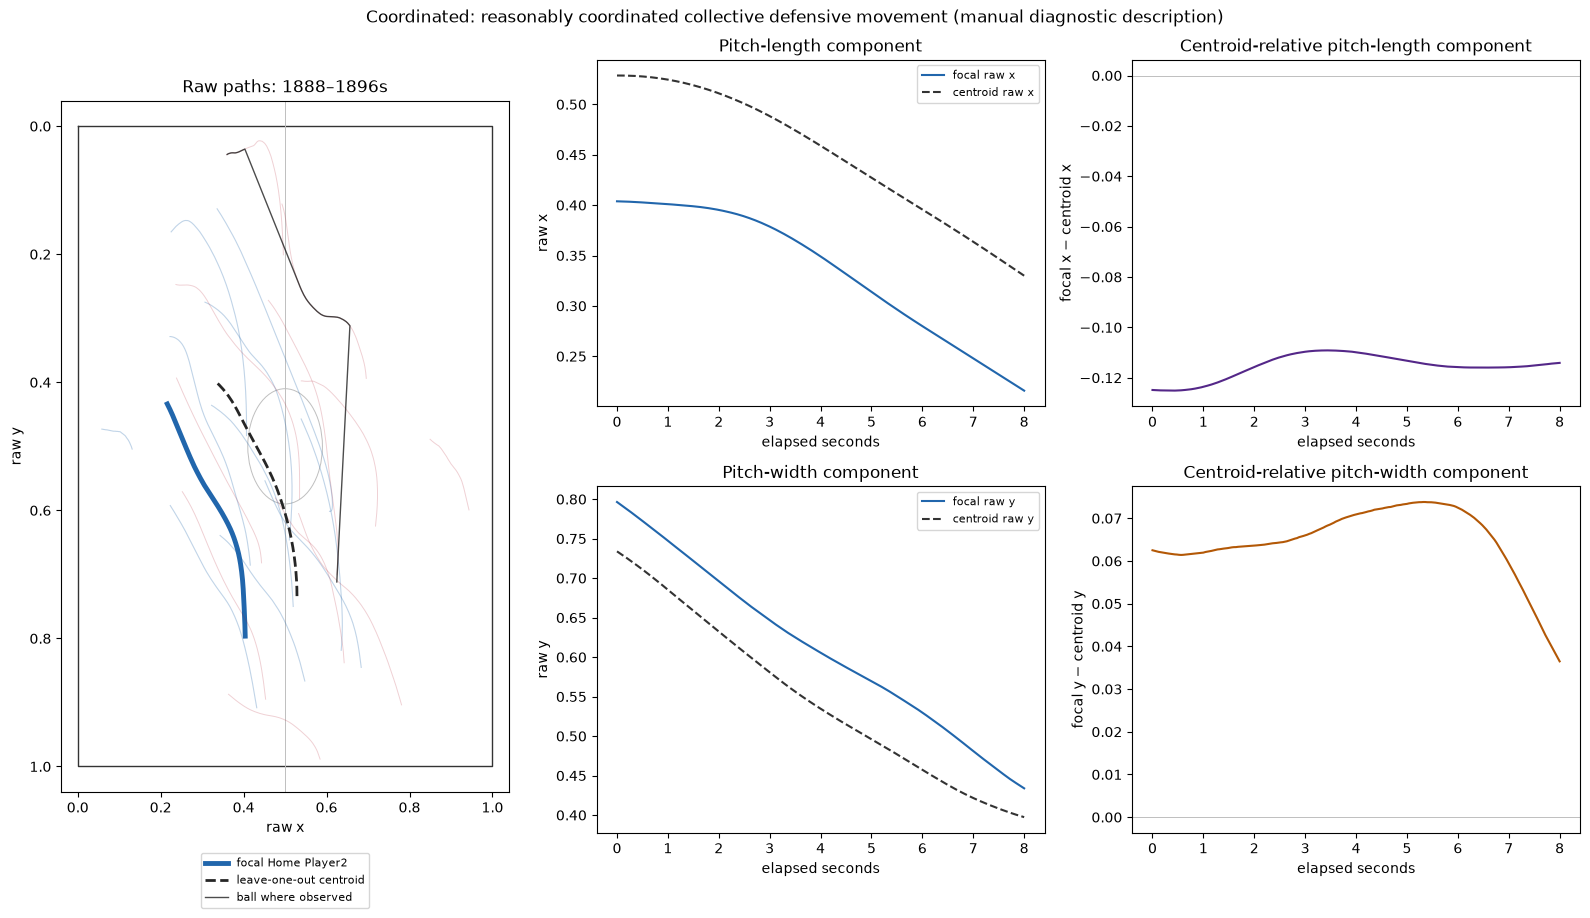

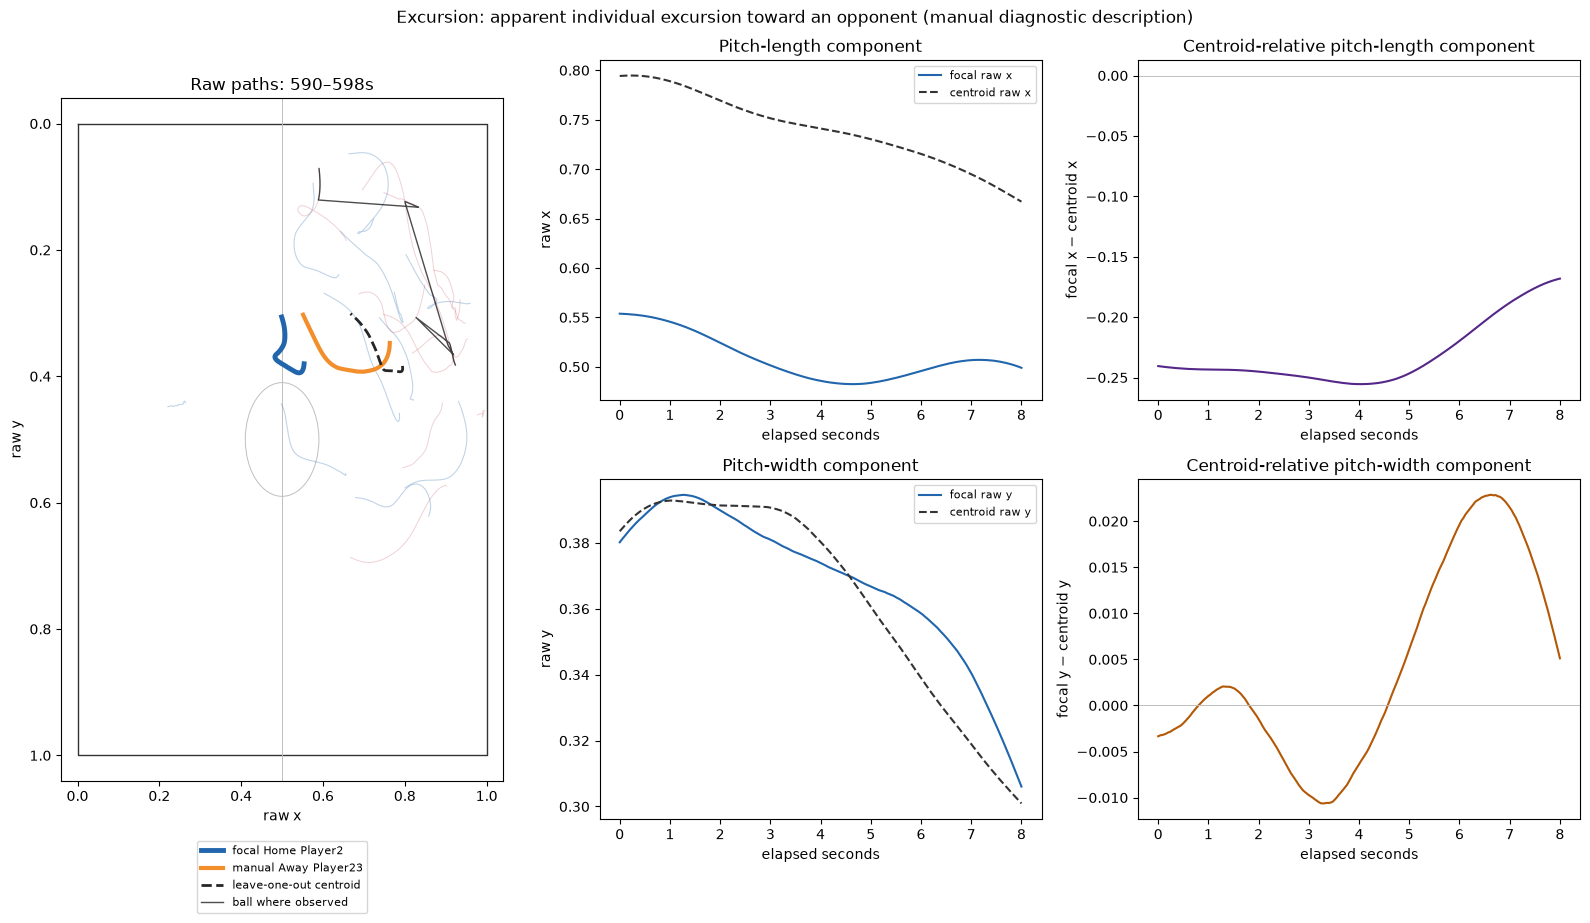

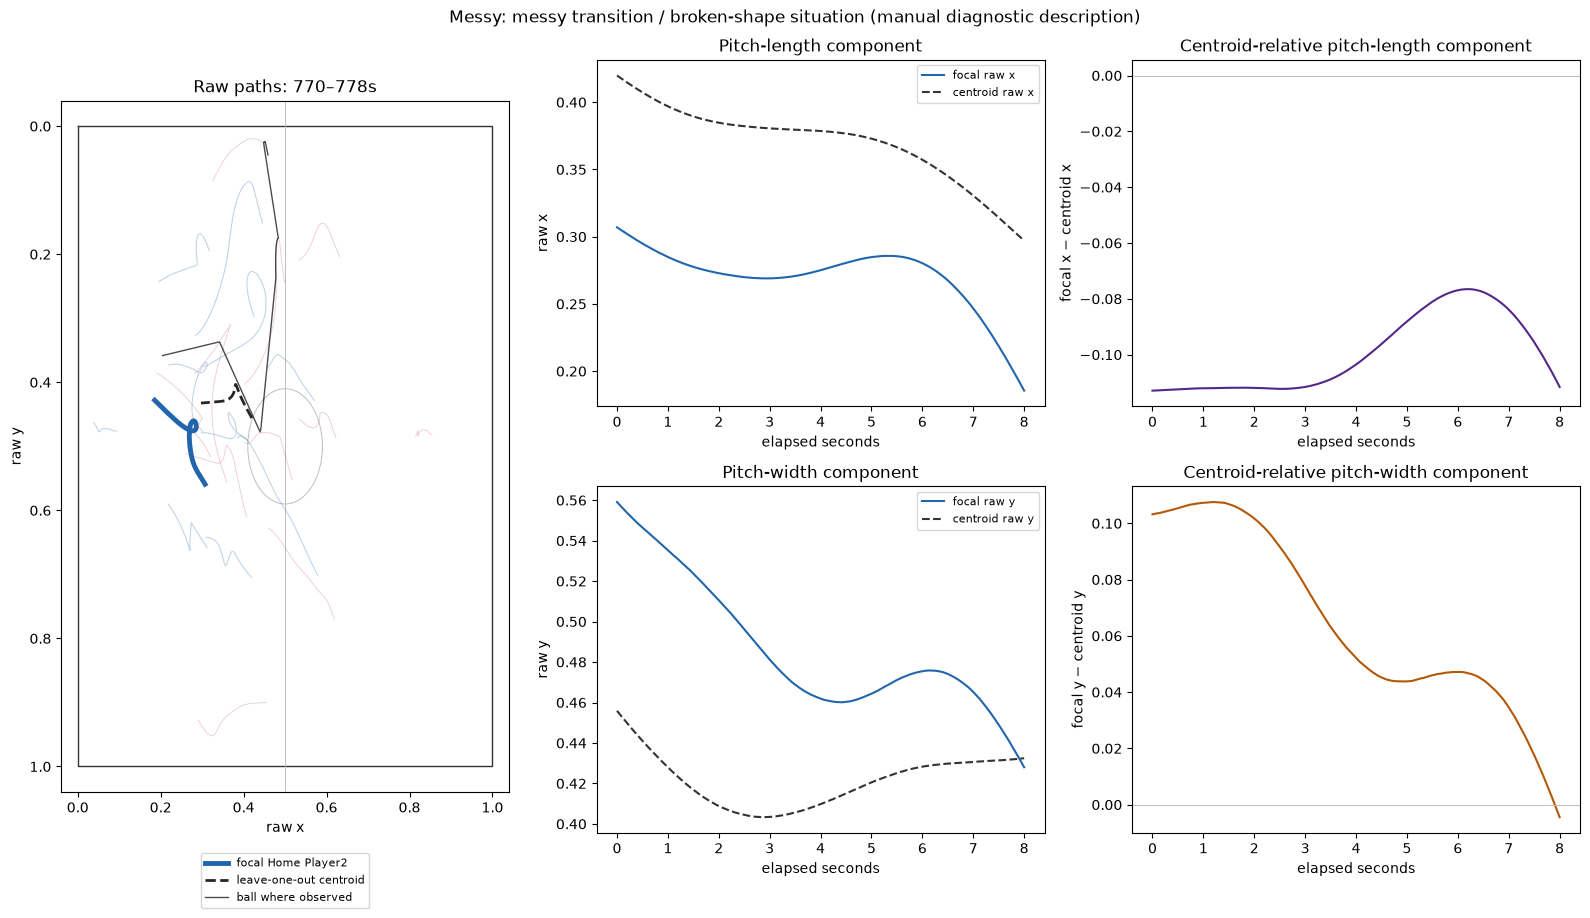

In [4]:
def draw_raw_pitch(ax, title):
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='0.2', linewidth=1.0)
    ax.axvline(0.5, color='0.75', linewidth=0.7)
    ax.add_patch(plt.Circle((0.5, 0.5), 0.09, fill=False, color='0.75', linewidth=0.7))
    ax.set(xlim=(-0.04, 1.04), ylim=(1.04, -0.04), xlabel='raw x', ylabel='raw y', title=title)
    ax.set_aspect(105 / 68)

def plot_diagnostic(name, home_window, away_window):
    specification = SEQUENCES[name]
    elapsed = home_window['Time [s]'] - home_window['Time [s]'].iloc[0]
    fig = plt.figure(figsize=(16, 9))
    grid = fig.add_gridspec(2, 3)
    pitch_ax = fig.add_subplot(grid[:, 0])
    raw_x_ax = fig.add_subplot(grid[0, 1])
    raw_y_ax = fig.add_subplot(grid[1, 1])
    relative_x_ax = fig.add_subplot(grid[0, 2])
    relative_y_ax = fig.add_subplot(grid[1, 2])

    draw_raw_pitch(pitch_ax, f"Raw paths: {specification['start_s']:.0f}–{specification['end_s']:.0f}s")
    for pid in home_players:
        valid = home_window[[f'Player{pid}_x', f'Player{pid}_y']].dropna()
        if not valid.empty:
            pitch_ax.plot(valid.iloc[:, 0], valid.iloc[:, 1], color='#2166ac', alpha=1 if pid == FOCAL_ID else 0.28, linewidth=3.5 if pid == FOCAL_ID else 0.8, label='focal Home Player2' if pid == FOCAL_ID else None)
    for pid in away_players:
        valid = away_window[[f'Player{pid}_x', f'Player{pid}_y']].dropna()
        if not valid.empty:
            is_manual_attacker = name == 'excursion' and pid == MANUAL_ATTACKER_ID
            pitch_ax.plot(valid.iloc[:, 0], valid.iloc[:, 1], color='#f28e2b' if is_manual_attacker else '#b2182b', alpha=1 if is_manual_attacker else 0.20, linewidth=3.0 if is_manual_attacker else 0.7, label='manual Away Player23' if is_manual_attacker else None)
    pitch_ax.plot(home_window['centroid_x'], home_window['centroid_y'], color='0.15', linestyle='--', linewidth=2.0, label='leave-one-out centroid')
    ball = home_window[['Ball_x', 'Ball_y']].dropna()
    if not ball.empty:
        pitch_ax.plot(ball['Ball_x'], ball['Ball_y'], color='black', linewidth=1.0, alpha=0.7, label='ball where observed')
    pitch_ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fontsize=8)

    raw_x_ax.plot(elapsed, home_window[f'Player{FOCAL_ID}_x'], color='#2166ac', label='focal raw x')
    raw_x_ax.plot(elapsed, home_window['centroid_x'], color='0.2', linestyle='--', label='centroid raw x')
    raw_x_ax.set(xlabel='elapsed seconds', ylabel='raw x', title='Pitch-length component')
    raw_x_ax.legend(fontsize=8)
    raw_y_ax.plot(elapsed, home_window[f'Player{FOCAL_ID}_y'], color='#2166ac', label='focal raw y')
    raw_y_ax.plot(elapsed, home_window['centroid_y'], color='0.2', linestyle='--', label='centroid raw y')
    raw_y_ax.set(xlabel='elapsed seconds', ylabel='raw y', title='Pitch-width component')
    raw_y_ax.legend(fontsize=8)
    relative_x_ax.plot(elapsed, home_window['relative_x'], color='#542788')
    relative_x_ax.axhline(0, color='0.75', linewidth=0.7)
    relative_x_ax.set(xlabel='elapsed seconds', ylabel='focal x − centroid x', title='Centroid-relative pitch-length component')
    relative_y_ax.plot(elapsed, home_window['relative_y'], color='#b35806')
    relative_y_ax.axhline(0, color='0.75', linewidth=0.7)
    relative_y_ax.set(xlabel='elapsed seconds', ylabel='focal y − centroid y', title='Centroid-relative pitch-width component')
    fig.suptitle(f"{name.title()}: {specification['description']} (manual diagnostic description)")
    fig.tight_layout()
    plt.show()

for name, (home_window, away_window) in diagnostics.items():
    plot_diagnostic(name, home_window, away_window)

## 5. Separate component spans as a visual aid

The table reports max-minus-min spans for x and y separately. It is not a score, classifier, threshold, or combined distance. It only supports reading the plots and is sensitive to the manually chosen window.

In [5]:
component_rows = []
for name, (home_window, _) in diagnostics.items():
    component_rows.append({
        'sequence': name,
        'raw_x_span': home_window[f'Player{FOCAL_ID}_x'].max() - home_window[f'Player{FOCAL_ID}_x'].min(),
        'centroid_relative_x_span': home_window['relative_x'].max() - home_window['relative_x'].min(),
        'raw_y_span': home_window[f'Player{FOCAL_ID}_y'].max() - home_window[f'Player{FOCAL_ID}_y'].min(),
        'centroid_relative_y_span': home_window['relative_y'].max() - home_window['relative_y'].min(),
    })
component_spans = pd.DataFrame(component_rows).set_index('sequence')
display(component_spans.round(5))

,raw_x_span,centroid_relative_x_span,raw_y_span,centroid_relative_y_span
sequence,,,,
coordinated,0.18793,0.01598,0.36254,0.03732
excursion,0.07127,0.08734,0.08854,0.03349
messy,0.12148,0.03637,0.13109,0.11201


## 6. Illustrative attacker-relative view for the excursion only

Away Player23 was selected manually by looking at the raw 590–598s frames. The choice is illustrative: it is not inferred, optimized, or treated as a true marking assignment or responsibility. Defender-relative-to-attacker coordinates are `Home Player2 − Away Player23`. The four aligned plots compare centroid-relative x, attacker-relative x, centroid-relative y, and attacker-relative y without smoothing, differentiation, segmentation, or thresholds.

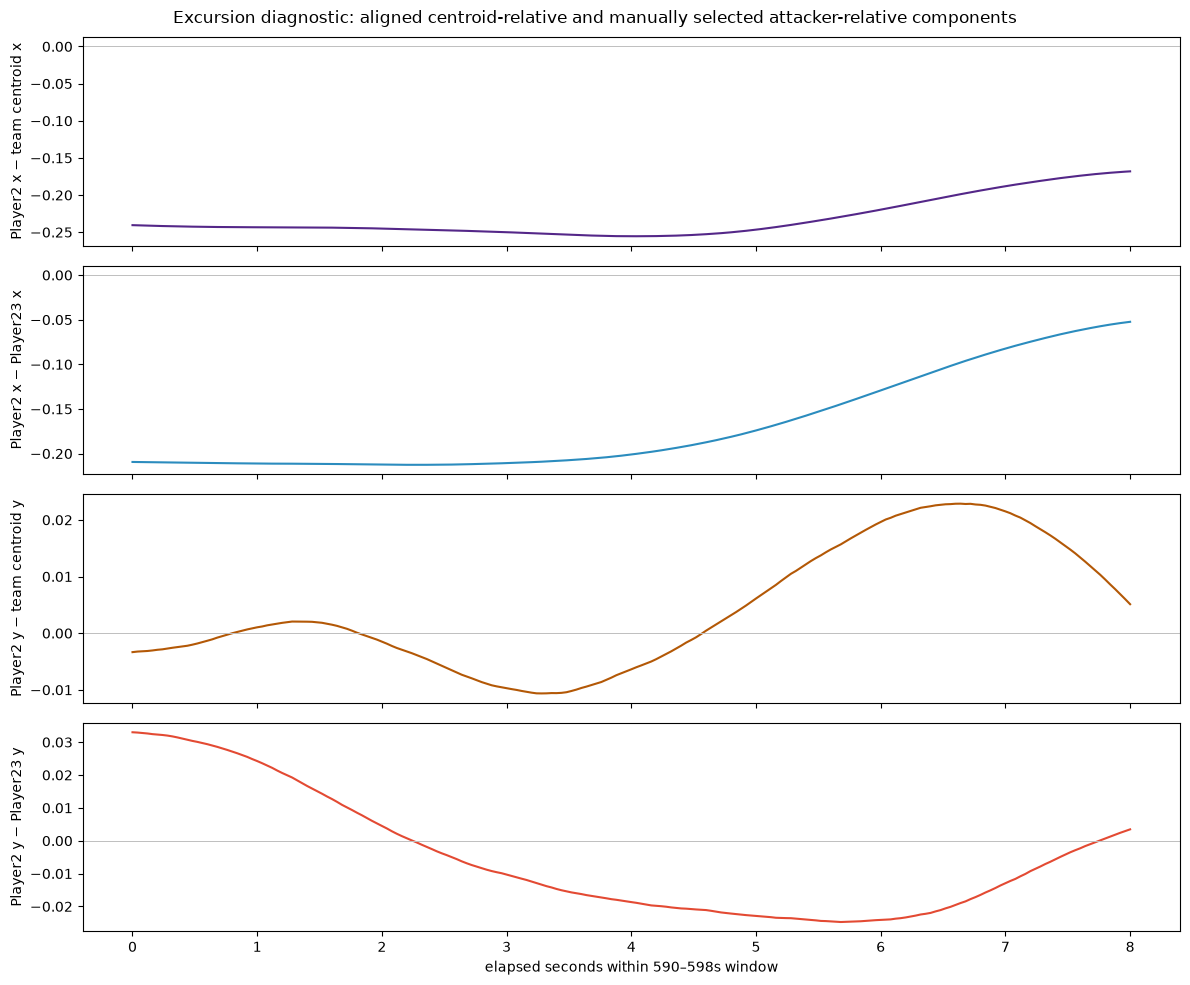

,x_span,y_span
representation,,
team-centroid-relative,0.08734,0.03349
Player23-relative (manual illustration),0.16025,0.05775


In [6]:
excursion_home, excursion_away = diagnostics['excursion']
paired = excursion_home[['Frame', 'Time [s]', f'Player{FOCAL_ID}_x', f'Player{FOCAL_ID}_y', 'relative_x', 'relative_y']].merge(
    excursion_away[['Frame', f'Player{MANUAL_ATTACKER_ID}_x', f'Player{MANUAL_ATTACKER_ID}_y']],
    on='Frame', how='inner', validate='one_to_one'
)
paired['defender_minus_attacker_x'] = paired[f'Player{FOCAL_ID}_x'] - paired[f'Player{MANUAL_ATTACKER_ID}_x']
paired['defender_minus_attacker_y'] = paired[f'Player{FOCAL_ID}_y'] - paired[f'Player{MANUAL_ATTACKER_ID}_y']
elapsed = paired['Time [s]'] - paired['Time [s]'].iloc[0]

series_to_plot = [
    ('relative_x', 'Player2 x − team centroid x', '#542788'),
    ('defender_minus_attacker_x', 'Player2 x − Player23 x', '#2b8cbe'),
    ('relative_y', 'Player2 y − team centroid y', '#b35806'),
    ('defender_minus_attacker_y', 'Player2 y − Player23 y', '#e34a33'),
]
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for axis, (column, label, color) in zip(axes, series_to_plot):
    axis.plot(elapsed, paired[column], color=color, linewidth=1.5)
    axis.axhline(0, color='0.75', linewidth=0.7)
    axis.set_ylabel(label)
axes[-1].set_xlabel('elapsed seconds within 590–598s window')
fig.suptitle('Excursion diagnostic: aligned centroid-relative and manually selected attacker-relative components')
fig.tight_layout()
plt.show()

excursion_component_spans = pd.DataFrame({
    'representation': ['team-centroid-relative', 'Player23-relative (manual illustration)'],
    'x_span': [
        paired['relative_x'].max() - paired['relative_x'].min(),
        paired['defender_minus_attacker_x'].max() - paired['defender_minus_attacker_x'].min(),
    ],
    'y_span': [
        paired['relative_y'].max() - paired['relative_y'].min(),
        paired['defender_minus_attacker_y'].max() - paired['defender_minus_attacker_y'].min(),
    ],
}).set_index('representation')
display(excursion_component_spans.round(5))

## 7. Diagnostic observations and challenges

### Coordinated sequence, 1888–1896s

Collective translation is strongly reduced in both separate components. The focal defender moves substantially in raw x and raw y with the team, while focal-minus-centroid x and y stay in much narrower bands. This is the clearest support in the tiny sample for the whole-team centroid as a useful translation reference.

### Apparent excursion, 590–598s

The transformation does not simply make the defender stationary. The team-centroid-relative spans are 0.08734 in x and 0.03349 in y; the manually selected Player23-relative spans are larger at 0.16025 in x and 0.05775 in y. These spans describe only this fixed window and are not thresholds or scores.

In the aligned plots, both x representations are visually fairly flat during roughly the opening two to three seconds, after which both change. The Player23-relative x relationship changes more strongly through the later portion, so it is not globally more stable than the centroid-relative representation. In y, the centroid-relative series remains within a narrower, gently changing band. The Player23-relative y series changes steadily through much of the window and reverses direction late. These timing descriptions are visual observations only; the window has not been segmented and the subperiods are not labeled as states.

Several soccer explanations remain compatible with the same geometry: Player2 may be following Player23; closing toward Player23 or nearby space; responding primarily to the ball or passing sequence; maintaining or restoring a defensive-line relationship; or merely co-moving with Player23 by coincidence while both react to another feature of play. The plots do not establish that Player23 is Player2's responsibility, nor do they identify intent, instruction, or a Track/Close state.

### Messy sequence, 770–778s

The centroid removes much of the focal defender's raw x translation but not the y divergence. The defending players visibly separate during the deep-ball sequence, so their mean is itself moving through a changing and arguably broken shape. A numerically well-defined centroid is not necessarily a meaningful structural location.

### Where the reference fails or challenges the framework

- The centroid treats all nine reference outfield players equally, regardless of unit, distance, phase, or missingness. A far-side attacker or midfielder can move the reference even when that player is irrelevant to the focal defender's local problem.
- Collective shape deformation is not the same as collective translation. The centroid can remove a global shift while leaving—or partly hiding—line rotation, expansion, compression, and local coordination.
- In a broken shape, the mean can lie in tactically empty space and can move because different teammates split in different directions.
- Separate x and y behavior matters: the same sequence can look structurally stable in one component and divergent in the other. A single distance would obscure that disagreement.
- The apparent excursion may be closing space, following an attacker, responding to the ball, or maintaining a local line. These plots cannot distinguish those explanations.
- The coordinated sequence shows that raw movement alone can overstate individual adjustment. Conversely, the messy sequence shows that centroid-relative stability in one component does not demonstrate structural responsibility.

**Stop condition:** this diagnostic comparison ends Phase 1A. It does not define Structure or Track, calculate a state score, select thresholds, or test another reference.